# Reconstructing experimental scenarios

October 2024 REALMORC

See Dvornik et al. (2026)

In [2]:
from glob import glob
import json
from pathlib import Path
import sys

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import yaml

from scipy.signal import peak_widths, find_peaks

# src directory
parent_dir = Path.cwd()
sys.path.append(str(parent_dir))
print(parent_dir)

/home/pim/pg-rad-analysis/src/notebooks/recreate_experimental


In [23]:
def get_sim_path_and_csv_name(i, base_dir="pgrad"):
    base_path = Path(base_dir)
    # Find all directories matching the pattern f"{i}_result_*"
    folders = list(base_path.glob(f"{i}_result_*"))
    if not folders:
        raise FileNotFoundError(f"No folder matching {i}_result_* found in {base_dir}")

    folder_name = folders[0].name
    print("Detected folder name:", folder_name)

    # Find all CSV files in the folder
    csv_files = list(folders[0].glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV file found in {folders[0]}")

    csv_name = csv_files[0].name
    print("Detected CSV name:", csv_name)

    return str(folders[0]), csv_name

In [3]:
def calc_fwhm(distance, counts):
    peak_max = np.max(counts)
    half_max = peak_max / 2.0

    # Find indices where counts cross half_max
    rising_idx = np.where(counts >= half_max)[0][0]
    falling_idx = np.where(counts[::-1] >= half_max)[0][0]
    falling_idx = len(counts) - 1 - falling_idx

    fwhm = distance[falling_idx] - distance[rising_idx]
    return fwhm, rising_idx, falling_idx, half_max

In [4]:
def set_conf_from_exp(conf, scene_name, csv_path, speed, along_path):
    conf['speed'] = speed
    conf['name'] = scene_name+'_F'+str(round(conf['speed']*3.6))
    
    conf['path']['file'] = csv_path
    
    conf['sources']['s1']['activity_MBq'] = param.loc[param['scenario'] == scene_name, 'source_activity_MBq'].item()
    
    pos = conf['sources']['s1']['position']
    pos['along_path'] = along_path
    pos['dist_from_path'] = param.loc[param['scenario'] == scene_name, 'distance_from_road_m'].item()
    pos['side'] = param.loc[param['scenario'] == scene_name, 'roadside'].item()
    
    conf['options']['bkg_cps'] = param.loc[param['scenario'] == scene_name, 'bkg_cps'].item()
    
    return conf

## Setup 1

## Setup 1 -- HPGe F15

In [5]:
SCENE = "Setup1"
EXP_CSV_PATH = 'exp_data/LU24_Setup1_F15_HPGe.xls'
df_exp = pd.read_excel(EXP_CSV_PATH)
df_exp.head()

,SeqNr,Date,Time,Long,Lat,East,North,RealT,LiveT,NrROIs,...,ROI_BR,ROI_BR(sd),ROI_K,ROI_K(sd),ROI_U,ROI_U(sd),ROI_T,ROI_T(sd),ROI_P_Net,ROI_P_Net(sd)
0,1,2024-10-15,12:20:15,13.016600,55.779208,1325041.5,6186871.4,1,0.90,10,...,3.33,1.92,1.11,1.11,1.11,1.11,0.00,0.00,-0.555,2.217769
1,2,2024-10-15,12:20:16,13.016525,55.779242,1325036.9,6186875.3,1,1.10,10,...,2.73,1.57,7.27,2.57,0.00,0.00,0.00,0.00,1.365,2.220315
2,3,2024-10-15,12:20:17,13.016475,55.779267,1325033.9,6186878.2,1,0.94,10,...,0.00,0.00,7.45,2.81,0.00,0.00,0.00,0.00,-0.535,2.123488
3,4,2024-10-15,12:20:18,13.016425,55.779300,1325030.9,6186882.0,1,0.92,10,...,1.09,1.09,9.78,3.26,0.00,0.00,1.09,1.09,1.080,2.178945
4,5,2024-10-15,12:20:19,13.016367,55.779333,1325027.4,6186885.9,1,0.94,10,...,1.06,1.06,1.06,1.06,0.00,0.00,1.06,1.06,1.600,1.836736


In [22]:
! cd pgrad && pgrad --config setup1_f15_hpge.yml --save

2026-05-17 12:34:57,589 - INFO: Landscape built successfully: Setup1_F15_HPGe
2026-05-17 12:34:57,612 - WARNING: PG-RAD currently does not support interpolation of experimental paths for export. Only ROI_P, ROI_BR and Dist will be saved.
2026-05-17 12:34:57,615 - INFO: Simulation output saved to setup1_f15_hpge_result_20260517_1234!


In [26]:
csv_path, roi_filename = get_sim_path_and_csv_name('setup1_f15_hpge')
BASE_DIR = Path("__file__").resolve().parent
CSV_DIR = Path(BASE_DIR.joinpath(csv_path))

params_file = Path(CSV_DIR.joinpath("parameters.json"))
params = json.load(params_file.open())

csv_file = Path(CSV_DIR.joinpath(roi_filename))
df_pgrad = pd.read_csv(csv_file)

Detected folder name: setup1_f15_hpge_result_20260517_1234
Detected CSV name: 1_src_0_cps_bkg_1251MBq_77m_205_283.csv


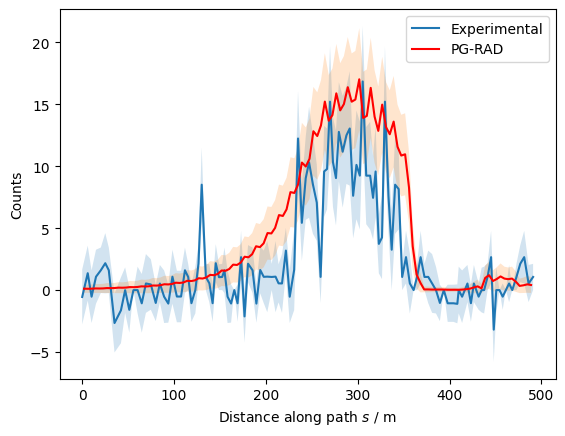

In [29]:
plt.plot(df_exp['Dist(m)'], df_exp['ROI_P_Net'], label='Experimental')

plt.fill_between(df_exp['Dist(m)'],
                 df_exp['ROI_P_Net'] - df_exp['ROI_P_Net(sd)'],
                 df_exp['ROI_P_Net'] + df_exp['ROI_P_Net(sd)'],
                 alpha=0.2)

plt.plot(df_pgrad['Dist'], df_pgrad['ROI_P'], color='r', label='PG-RAD')
plt.fill_between(df_pgrad['Dist'],
                 df_pgrad['ROI_P'] - np.sqrt(df_pgrad['ROI_P']),
                 df_pgrad['ROI_P'] + np.sqrt(df_pgrad['ROI_P']),
                 alpha=0.2)
plt.legend()
# plt.title('Oct. 2024, Setup 1, HPGe F15, net counts')
plt.xlabel("Distance along path $s$ / m")
plt.ylabel("Counts")
plt.savefig('setup1_HPGe.png')

## Setup 1 -- NaI F30

In [30]:
SCENE = "Setup1"
EXP_CSV_PATH = 'exp_data/LU24_Setup1_F30 1.csv'

In [31]:
df_exp = pd.read_csv(EXP_CSV_PATH)
df_exp.head()

,SeqNr,Date,Time,Long,Lat,East,North,RealT,LiveT,NrROIs,...,ROI_P,ROI_P(sd),ROI_BR,ROI_BR(sd),ROI_K,ROI_K(sd),ROI_U,ROI_U(sd),ROI_T,ROI_T(sd)
0,1,2024-10-15,12:16:12,13.015575,55.780926,1324980.6,6186958.4,1.0,1.02,10,...,54.90,7.34,53.92,7.27,68.63,8.20,5.88,2.40,3.92,1.96
1,2,2024-10-15,12:16:13,13.015529,55.780000,1324977.9,6186962.6,1.0,1.13,10,...,67.45,7.72,53.41,6.87,61.33,7.36,8.89,2.80,5.37,2.18
2,3,2024-10-15,12:16:13,13.015483,55.780036,1324975.2,6186966.8,1.0,1.18,10,...,70.99,7.77,53.54,6.75,53.46,6.75,11.41,3.12,7.20,2.48
3,4,2024-10-15,12:16:14,13.015434,55.780072,1324972.3,6186970.9,1.0,1.08,10,...,56.92,7.28,54.97,7.15,46.37,6.57,12.67,3.43,9.40,2.96
4,5,2024-10-15,12:16:14,13.015385,55.780107,1324969.3,6186974.9,1.0,0.98,10,...,48.69,7.04,56.26,7.56,47.73,6.97,13.04,3.64,9.80,3.16


In [5]:
plt.plot

results here are copied from version PG-RAD with time integration. 

In [7]:
roi_p = np.array([np.float64(94.5475236212477), np.float64(94.81993813972608), np.float64(86.90641977215665), np.float64(96.12703382717984), np.float64(96.44839357968945), np.float64(94.25974464017517), np.float64(101.5801225874697), np.float64(101.08752684391774), np.float64(102.23219328578577), np.float64(109.26898456344419), np.float64(106.49861351919357), np.float64(119.71979960517363), np.float64(130.16471865159383), np.float64(131.8139867968502), np.float64(156.38576585192283), np.float64(170.23974355484285), np.float64(172.88329375264144), np.float64(199.9332881869512), np.float64(208.59636357811115), np.float64(212.91782240629325), np.float64(240.48610754008004), np.float64(228.4206273462057), np.float64(235.73802282423225), np.float64(219.60975962768237), np.float64(202.44236321128759), np.float64(207.48007633789268), np.float64(195.60426429515755), np.float64(178.14542273561696), np.float64(175.27333477968892), np.float64(166.1719647479117), np.float64(113.65936849059912), np.float64(104.90102989440253), np.float64(85.80479578351765), np.float64(92.69823993695353), np.float64(91.51209998416442), np.float64(89.47715275627608), np.float64(90.48676014785502), np.float64(97.79855468931629), np.float64(93.46560845969134), np.float64(94.1812268850084), np.float64(96.30852184156089), np.float64(89.17025402820676), np.float64(97.64013064118447)])
dist = [np.float64(4.005920061846811), np.float64(12.518500193271285), np.float64(20.78071032083033), np.float64(29.042920448389378), np.float64(37.55550057981385), np.float64(45.8177107073729), np.float64(54.07992083493195), np.float64(62.59250096635643), np.float64(70.85471109391547), np.float64(79.11692122147453), np.float64(87.37913134903357), np.float64(95.64134147659261), np.float64(104.15392160801709), np.float64(112.41613173557613), np.float64(120.67834186313517), np.float64(129.19092199455966), np.float64(137.4531321221187), np.float64(145.71534224967775), np.float64(154.22792238110222), np.float64(162.49013250866125), np.float64(170.7523426362203), np.float64(179.01455276377936), np.float64(187.2767628913384), np.float64(195.78934302276292), np.float64(204.05155315032192), np.float64(212.31376327788098), np.float64(220.82634340930545), np.float64(229.08855353686448), np.float64(237.35076366442354), np.float64(245.86334379584804), np.float64(254.12555392340707), np.float64(262.38776405096604), np.float64(270.64997417852516), np.float64(278.9121843060842), np.float64(287.42476443750866), np.float64(295.6869745650677), np.float64(303.9491846926268), np.float64(312.4617648240513), np.float64(320.72397495161033), np.float64(328.98618507916933), np.float64(337.49876521059383), np.float64(345.7609753381529), np.float64(354.0231854657119)]

In [8]:
mean_bkg_exp = np.mean(df_exp['ROI_BR'])
mean_bkg_pgrad = 90

fwhm_exp, left_exp, right_exp, half_max_exp = calc_fwhm(df_exp['Dist(m)'], df_exp['ROI_P']-mean_bkg_exp)
fwhm_pgrad, left_pgrad, right_pgrad, half_max_pgrad = calc_fwhm(dist, roi_p-mean_bkg_pgrad)

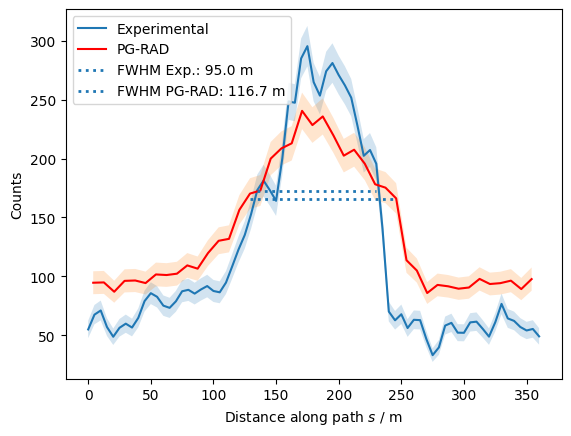

In [9]:
plt.plot(df_exp['Dist(m)'], df_exp['ROI_P'], label='Experimental')
plt.fill_between(df_exp['Dist(m)'],
                 df_exp['ROI_P'] - np.sqrt(df_exp['ROI_P']),
                 df_exp['ROI_P'] + np.sqrt(df_exp['ROI_P']),
                 alpha=0.2)
plt.plot(dist, roi_p, color='r', label='PG-RAD')
plt.fill_between(dist,
                 roi_p - np.sqrt(roi_p),
                 roi_p + np.sqrt(roi_p),
                 alpha=0.2)

plt.hlines(y=half_max_exp+mean_bkg_exp, xmin=df_exp['Dist(m)'][left_exp], xmax=df_exp['Dist(m)'][right_exp], linestyle=":", linewidth=2, label=f"FWHM Exp.: {fwhm_exp:.1f} m")
plt.hlines(y=half_max_pgrad+mean_bkg_pgrad, xmin=dist[left_pgrad], xmax=dist[right_pgrad], linestyle=":", linewidth=2, label=f"FWHM PG-RAD: {fwhm_pgrad:.1f} m")

plt.legend()
plt.xlabel("Distance along path $s$ / m")
plt.ylabel("Counts")
plt.savefig('setup1.png')

## Long road scenarios

The long road scenarios cover 70+ km of road. We do not simulate the entire scenario, but rather around the source location.

The indices for the source locations are:

- Road2: 14533
- Road3: 11184


#### Road2

In [10]:
SCENE = "Road2"
LOC = 14533
EXP_CSV_PATH = 'exp_data/Road2_NaIR_ROI_CPS.csv'

With scenario selected, we identify peak in CPS.

In [11]:
df_exp = pd.read_csv(f'exp_data/{SCENE}_NaIR_ROI_CPS.csv')
df_exp

,SeqNr,Long,Lat,East,North,RealT,LiveT,Dist(m),ROI_A,ROI_A(sd),...,ROI_P,ROI_P(sd),ROI_BR,ROI_BR(sd),ROI_K,ROI_K(sd),ROI_U,ROI_U(sd),ROI_T,ROI_T(sd)
0,1,13.156408,56.134679,1335323.7,6225982.7,1.00,1.00,0,1076.00,32.80,...,139.00,11.79,99.00,9.95,108.00,10.39,18.00,4.24,16.00,4
1,2,13.156335,56.133698,1335319.1,6225981.3,1.00,1.02,5,1151.10,33.64,...,158.91,12.50,118.22,10.78,129.17,11.27,16.51,4.03,21.70,4.62
2,3,13.156257,56.133690,1335314.2,6225980.6,1.00,0.98,10,1247.38,35.63,...,161.11,12.80,121.37,11.11,145.47,12.17,26.14,5.16,27.11,5.25
3,4,13.156195,56.133662,1335310.3,6225977.6,1.00,0.99,15,1202.95,34.84,...,167.85,13.01,115.69,10.80,126.87,11.31,25.44,5.07,14.95,3.88
4,5,13.156130,56.133635,1335306.1,6225974.8,1.00,1.00,20,1136.16,33.68,...,163.94,12.79,129.12,11.35,122.44,11.06,22.81,4.77,15.11,3.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15517,15518,13.912431,56.100075,1382214.4,6220690.1,1.07,1.09,77585,1057.73,31.09,...,133.49,11.05,122.50,10.58,159.70,12.08,14.32,3.62,17.73,4.03
15518,15519,13.912494,56.100063,1382218.3,6220688.6,0.99,0.97,77590,1064.75,33.13,...,129.06,11.53,123.77,11.29,161.86,12.92,21.01,4.65,18.52,4.37
15519,15520,13.912533,56.100102,1382220.9,6220692.9,1.00,1.00,77595,1055.67,32.41,...,146.59,12.08,95.85,9.77,178.20,13.32,18.12,4.25,8.83,2.96
15520,15521,13.912525,56.100146,1382220.5,6220697.8,1.00,1.00,77600,1038.50,32.23,...,142.29,11.93,118.14,10.87,137.10,11.71,9.06,3.01,18.00,4.24


In [12]:
subset_df = df_exp[LOC-100 : LOC+100]
subset_df.to_csv('exp_data/Road2_NaIR_ROI_CPS_subset.csv')
source_loc = float(subset_df.loc[LOC+100-1]['Dist(m)'] - subset_df.loc[subset_df['ROI_P'].idxmax()]['Dist(m)'])
source_loc

470.0

In [13]:
roi_p = [np.float64(130.69102683729525), np.float64(127.69124270179012), np.float64(125.62256798334457), np.float64(130.93570959501727), np.float64(124.63513176102347), np.float64(127.4441185327564), np.float64(125.91972128661507), np.float64(125.9991314377709), np.float64(125.58447762393847), np.float64(128.32535207505208), np.float64(126.01069836914289), np.float64(127.99005646326538), np.float64(132.22660167687502), np.float64(125.13365833927304), np.float64(129.2942207092617), np.float64(129.09659626204495), np.float64(125.91794581456122), np.float64(128.7590163199019), np.float64(131.17029493696373), np.float64(126.77642375679346), np.float64(125.14655439055605), np.float64(130.82672675025213), np.float64(128.6768165390411), np.float64(129.7136415018753), np.float64(134.59252839830333), np.float64(130.8139333848506), np.float64(134.12399610595529), np.float64(138.53453079291467), np.float64(139.73942875137178), np.float64(146.06962752708722), np.float64(151.11575191224048), np.float64(155.08079757437463), np.float64(161.98931678447556), np.float64(164.7211228432717), np.float64(154.22997576201357), np.float64(152.22407645014215), np.float64(147.40960233136047), np.float64(142.97518932067047), np.float64(135.2213727195507), np.float64(131.7027540050161), np.float64(131.7971927388234), np.float64(129.67311606083962), np.float64(130.95255125727945), np.float64(126.76603739539935), np.float64(124.55689265872327), np.float64(125.21483294785484), np.float64(129.3589764936076), np.float64(125.69546384493128), np.float64(123.79468000608941), np.float64(129.42890848632874), np.float64(126.93099603590386), np.float64(126.7797814588731), np.float64(133.93928997682653), np.float64(123.0866945758511), np.float64(126.84132150484189), np.float64(127.70094896953032), np.float64(125.12474739260267), np.float64(125.49713899875945), np.float64(130.67078103217256)]
dist = [np.float64(8.253981674327486), np.float64(25.012065679780264), np.float64(41.52002902843523), np.float64(58.27811303388801), np.float64(75.03619703934078), np.float64(91.54416038799576), np.float64(108.30224439344853), np.float64(125.0603283989013), np.float64(141.5682917475563), np.float64(158.32637575300905), np.float64(175.0844597584618), np.float64(191.5924231071168), np.float64(208.35050711256955), np.float64(225.10859111802236), np.float64(241.61655446667731), np.float64(258.3746384721301), np.float64(275.13272247758283), np.float64(291.6406858262378), np.float64(308.39876983169063), np.float64(325.1568538371434), np.float64(341.6648171857984), np.float64(358.4229011912511), np.float64(375.1809851967039), np.float64(391.6889485453588), np.float64(408.4470325508116), np.float64(425.2051165562645), np.float64(441.7130799049194), np.float64(458.4711639103722), np.float64(475.22924791582494), np.float64(491.7372112644799), np.float64(508.49529526993274), np.float64(525.2533792753854), np.float64(541.7613426240405), np.float64(558.5194266294931), np.float64(575.2775106349459), np.float64(591.7854739836009), np.float64(608.2934373322558), np.float64(625.0515213377086), np.float64(641.8096053431614), np.float64(658.3175686918165), np.float64(675.0756526972692), np.float64(691.8337367027219), np.float64(708.3417000513768), np.float64(725.0997840568298), np.float64(741.8578680622826), np.float64(758.3658314109375), np.float64(775.1239154163902), np.float64(791.881999421843), np.float64(808.389962770498), np.float64(825.1480467759508), np.float64(841.9061307814035), np.float64(858.4140941300586), np.float64(875.1721781355112), np.float64(891.9302621409641), np.float64(908.438225489619), np.float64(925.1963094950719), np.float64(941.9543935005245), np.float64(958.4623568491795), np.float64(975.2204408546322)]

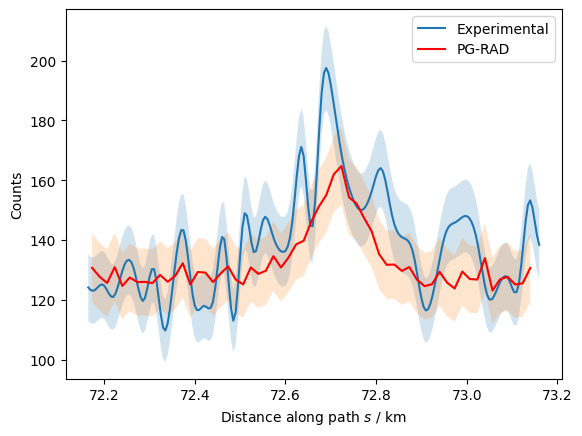

In [14]:
plt.plot(subset_df['Dist(m)']/1E3, subset_df['ROI_P'], label='Experimental')
plt.fill_between(subset_df['Dist(m)']/1E3,
                 subset_df['ROI_P'] - np.sqrt(subset_df['ROI_P']),
                 subset_df['ROI_P'] + np.sqrt(subset_df['ROI_P']),
                 alpha=0.2)

plt.plot((np.array(dist)+subset_df.loc[LOC-100]['Dist(m)'])/1E3, roi_p, color='r', label='PG-RAD')
plt.fill_between((np.array(dist)+subset_df.loc[LOC-100]['Dist(m)'])/1E3,
                 roi_p - np.sqrt(roi_p),
                 roi_p + np.sqrt(roi_p),
                 alpha=0.2)
plt.legend()
plt.xlabel("Distance along path $s$ / km")
plt.ylabel("Counts")
plt.savefig('road2.png')

#### Road3

In [15]:
SCENE = "Road3"
LOC = 11184
EXP_CSV_PATH = 'exp_data/Road3_NaIR_ROI_CPS.csv'

df_exp = pd.read_csv(f'exp_data/{SCENE}_NaIR_ROI_CPS.csv')
subset_df = df_exp[LOC-100 : LOC+100]
subset_df.to_csv('exp_data/Road3_NaIR_ROI_CPS_subset.csv')
source_loc = float(subset_df.loc[LOC+100-1]['Dist(m)'] - subset_df.loc[subset_df['ROI_P'].idxmax()]['Dist(m)'])
source_loc

495.0

In [16]:
roi_p = [np.float64(106.98080015933348), np.float64(101.59403997407045), np.float64(103.0788337200504), np.float64(106.17556569130436), np.float64(102.77748954254282), np.float64(101.36599957166914), np.float64(108.06321306051777), np.float64(104.62079281564618), np.float64(103.45931063239382), np.float64(102.27812042210239), np.float64(102.47497911048816), np.float64(103.08567398997377), np.float64(105.85855720168942), np.float64(107.19124302447023), np.float64(105.76750918572259), np.float64(107.30359529009564), np.float64(100.98837386866688), np.float64(105.93079712299749), np.float64(110.76928198207452), np.float64(105.41278138030388), np.float64(108.06271354114337), np.float64(111.46713768734215), np.float64(106.72416280606116), np.float64(111.19745291110837), np.float64(118.04662446687206), np.float64(128.48290043921068), np.float64(134.99865646590246), np.float64(157.64398513587804), np.float64(191.30500235372284), np.float64(197.88933741211912), np.float64(197.01546508307624), np.float64(181.88352600275664), np.float64(153.78613860546193), np.float64(138.10009665399596), np.float64(128.72535558115032), np.float64(114.10598020680794), np.float64(110.69553056361646), np.float64(110.62893068378344), np.float64(109.26875948747944), np.float64(104.84022167368076), np.float64(106.52983298626668), np.float64(105.27419626851314), np.float64(101.37763514981488), np.float64(105.93513118200197), np.float64(104.04487245059285), np.float64(100.7393368080932), np.float64(109.74147827504878), np.float64(99.67135240642614), np.float64(103.12723524150142), np.float64(101.81275055774569), np.float64(101.87265407743276), np.float64(106.94534810602468), np.float64(103.37111199111848), np.float64(105.67692363326107), np.float64(102.5548849917258), np.float64(99.90759003494976), np.float64(105.87766353402606), np.float64(103.29568316699493), np.float64(105.00569370621209)]
dist = [np.float64(8.255090914573728), np.float64(25.01542701385979), np.float64(41.52560884300725), np.float64(58.2859449422933), np.float64(75.04628104157936), np.float64(91.55646287072682), np.float64(108.31679897001288), np.float64(125.07713506929893), np.float64(141.5873168984464), np.float64(158.34765299773247), np.float64(175.10798909701853), np.float64(191.61817092616593), np.float64(208.37850702545202), np.float64(225.1388431247381), np.float64(241.64902495388557), np.float64(258.40936105317155), np.float64(275.1696971524576), np.float64(291.6798789816051), np.float64(308.44021508089116), np.float64(325.20055118017723), np.float64(341.7107330093247), np.float64(358.4710691086107), np.float64(375.23140520789684), np.float64(391.7415870370442), np.float64(408.2517688661917), np.float64(425.01210496547776), np.float64(441.7724410647638), np.float64(458.28262289391125), np.float64(475.0429589931974), np.float64(491.8032950924834), np.float64(508.3134769216309), np.float64(525.0738130209169), np.float64(541.8341491202028), np.float64(558.3443309493505), np.float64(575.1046670486367), np.float64(591.8650031479226), np.float64(608.3751849770699), np.float64(625.135521076356), np.float64(641.8958571756422), np.float64(658.4060390047896), np.float64(675.1663751040757), np.float64(691.9267112033616), np.float64(708.4368930325091), np.float64(725.1972291317952), np.float64(741.9575652310812), np.float64(758.4677470602287), np.float64(775.2280831595148), np.float64(791.9884192588008), np.float64(808.4986010879484), np.float64(825.0087829170959), np.float64(841.7691190163818), np.float64(858.5294551156677), np.float64(875.0396369448154), np.float64(891.7999730441015), np.float64(908.5603091433875), np.float64(925.0704909725349), np.float64(941.8308270718209), np.float64(958.5911631711072), np.float64(975.1013450002545)]

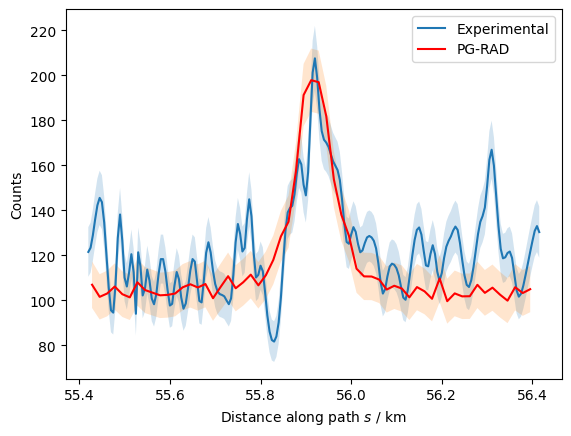

In [17]:
plt.plot(subset_df['Dist(m)']/1E3, subset_df['ROI_P'], label='Experimental')
plt.fill_between(subset_df['Dist(m)']/1E3,
                 subset_df['ROI_P'] - np.sqrt(subset_df['ROI_P']),
                 subset_df['ROI_P'] + np.sqrt(subset_df['ROI_P']),
                 alpha=0.2)

plt.plot((np.array(dist)+subset_df.loc[LOC-100]['Dist(m)'])/1E3, roi_p, color='r', label='PG-RAD')
plt.fill_between((np.array(dist)+subset_df.loc[LOC-100]['Dist(m)'])/1E3,
                 roi_p - np.sqrt(roi_p),
                 roi_p + np.sqrt(roi_p),
                 alpha=0.2)
plt.legend()
plt.xlabel("Distance along path $s$ / km")
plt.ylabel("Counts")
plt.savefig('road3.png')